In [1]:
import pandas as pd
import numpy as np

In [2]:
import sys 
from pathlib import Path

BASE_DIR = Path().resolve()
PROJECT_ROOT = BASE_DIR.parent   #to go un up the the root
DATA_DIR = PROJECT_ROOT / "data" 

In [3]:
df=pd.read_csv(DATA_DIR / 'processed_data.csv')

In [4]:
df

,subject,exercise,time index,acc_x_u1,acc_x_u2,acc_x_u3,acc_x_u4,acc_x_u5,acc_y_u1,acc_y_u2,...,gyr_mag_u3,mag_mag_u3,acc_mag_u4,gyr_mag_u4,mag_mag_u4,acc_mag_u5,gyr_mag_u5,mag_mag_u5,most_active_unit,label
0,s1,e1,1,-9.685645,-9.268303,-3.490739,9.018139,-4.191311,-1.645149,2.981149,...,0.026881,0.822163,9.757600,0.014221,0.787898,9.813711,0.008580,0.762010,u2,correct
1,s1,e1,2,-9.648184,-9.260987,-3.445827,9.044963,-4.188912,-1.645353,2.958806,...,0.024231,0.821653,9.772105,0.034212,0.786162,9.793846,0.016693,0.761298,u2,correct
2,s1,e1,3,-9.700570,-9.260972,-3.475073,9.077281,-4.181551,-1.615223,2.966184,...,0.022021,0.822319,9.843089,0.033648,0.786961,9.813023,0.019365,0.761755,u2,correct
3,s1,e1,4,-9.685627,-9.260754,-3.474895,9.032722,-4.181585,-1.630183,3.010663,...,0.028818,0.820716,9.772934,0.018946,0.786664,9.798967,0.013698,0.762076,u2,correct
4,s1,e1,5,-9.655697,-9.260783,-3.467499,8.993878,-4.186467,-1.630194,2.995905,...,0.030181,0.820915,9.749011,0.031250,0.787620,9.797769,0.024000,0.761082,u2,correct
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
158353,s5,e8,5088,-1.527953,-9.674701,1.978098,6.922647,1.876655,-9.665978,1.265019,...,0.025282,0.899167,9.785526,0.023613,0.931566,9.813756,0.016301,0.932956,u2,low_amplitude
158354,s5,e8,5089,-1.527883,-9.689552,1.962998,6.927831,1.879036,-9.628649,1.265227,...,0.029466,0.899541,9.799846,0.006585,0.933682,9.722012,0.018409,0.932929,u2,low_amplitude
158355,s5,e8,5090,-1.542963,-9.734492,1.992746,6.922948,1.859529,-9.665803,1.228453,...,0.015660,0.899638,9.787181,0.018174,0.932079,9.736470,0.024049,0.932213,u2,low_amplitude
158356,s5,e8,5091,-1.542924,-9.689592,1.948238,6.898431,1.854705,-9.650913,1.272519,...,0.019069,0.898545,9.742179,0.027622,0.933872,9.773205,0.008863,0.933159,u2,low_amplitude


Building dataset  (n_reps=10, active-unit-only, v13+skew_kurt_corr features)...
  1200 samples  ×  35 signal features

LOSO evaluation:
  s1:  train=0.935  test=0.588  gap=0.348
  s2:  train=0.923  test=0.767  gap=0.156
  s3:  train=0.917  test=0.863  gap=0.054
  s4:  train=0.933  test=0.708  gap=0.225
  s5:  train=0.922  test=0.750  gap=0.172

Summary:
 mean_train  mean_test  mean_gap  std_test  n_features
      0.926      0.735     0.191    0.0999          43


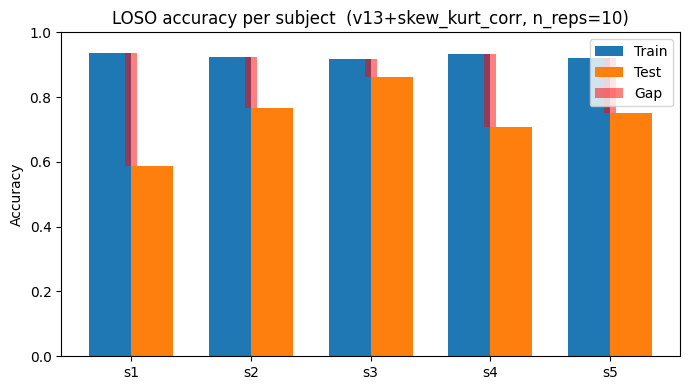

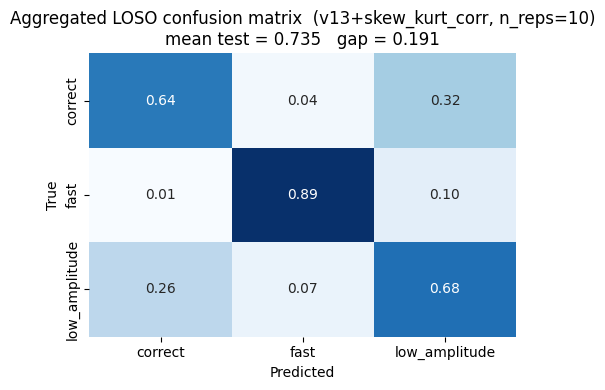

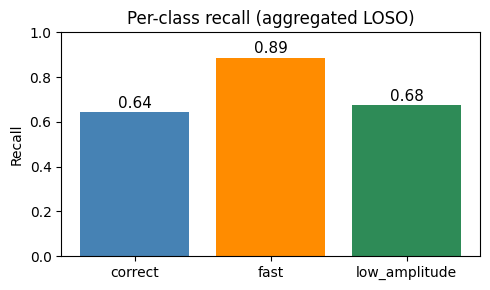

In [5]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import skew, kurtosis
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import accuracy_score, confusion_matrix
from xgboost import XGBClassifier


# =========================================================
# 1. ACTIVE COLUMN NAMES
# CHANGED:
# - keeping only accelerometer and gyroscope active magnitudes
# =========================================================
ACTIVE_COLS = ["acc_mag_active", "gyr_mag_active"]
LABELS_ORDER = ["correct", "fast", "low_amplitude"]


# =========================================================
# 2. FEATURE EXTRACTOR — v13 + skew/kurtosis + cross-corr
# CHANGED:
# - added skew and kurtosis per sensor
# - added acc_gyr_corr cross-sensor correlation
# =========================================================
def extract_features_v13(segment, sensor_cols=ACTIVE_COLS):
    features = {}

    for col in sensor_cols:
        x = segment[col].to_numpy().astype(float)
        n = len(x)
        x_c = x - np.mean(x)

        # baseline
        features[f"{col}_mean"] = np.mean(x)
        features[f"{col}_std"] = np.std(x)
        features[f"{col}_median"] = np.median(x)

        # amplitude
        features[f"{col}_range"] = np.max(x) - np.min(x)
        q25, q75 = np.percentile(x, [25, 75])
        features[f"{col}_iqr"] = q75 - q25
        p10, p90 = np.percentile(x, [10, 90])
        features[f"{col}_spread"] = p90 - p10
        features[f"{col}_rms"] = np.sqrt(np.mean(x ** 2))

        # CHANGED: distribution shape
        features[f"{col}_skew"] = float(skew(x))
        features[f"{col}_kurtosis"] = float(kurtosis(x))

        # temporal asymmetry
        mid = n // 2
        first = x[:mid]
        second = x[mid:]

        rms_first = np.sqrt(np.mean(first ** 2)) if len(first) > 0 else 0.0
        rms_second = np.sqrt(np.mean(second ** 2)) if len(second) > 0 else 0.0
        features[f"{col}_energy_diff"] = rms_first - rms_second

        # spectral
        fft_mag = np.abs(np.fft.rfft(x_c))
        power = fft_mag ** 2
        total = power.sum()

        if total > 0 and len(power) > 1:
            pn = power / total
            dom_idx = int(np.argmax(power[1:]) + 1)

            features[f"{col}_dom_freq_idx"] = dom_idx
            features[f"{col}_dom_freq_power"] = float(power[dom_idx])
            features[f"{col}_dom_power_ratio"] = float(power[dom_idx] / total)
            features[f"{col}_spectral_entropy"] = float(
                -np.sum(pn * np.log(pn + 1e-12))
            )

            freqs = np.arange(len(power))
            features[f"{col}_spectral_centroid"] = float(
                np.sum(freqs * power) / (total + 1e-12)
            )

            lo = np.sum(power[1:4]) if len(power) > 4 else np.sum(power[1:])
            hi = np.sum(power[4:]) if len(power) > 4 else 0.0
            features[f"{col}_band_ratio"] = float(hi / (lo + 1e-12))

            features[f"{col}_zcr"] = np.sum(
                np.diff(np.sign(x_c)) != 0
            ) / max(n - 1, 1)
        else:
            for k in (
                "dom_freq_idx", "dom_freq_power", "dom_power_ratio",
                "spectral_entropy", "spectral_centroid", "band_ratio", "zcr"
            ):
                features[f"{col}_{k}"] = 0.0

    # CHANGED: cross-sensor correlation
    acc = segment[sensor_cols[0]].to_numpy().astype(float)
    gyr = segment[sensor_cols[1]].to_numpy().astype(float)
    features["acc_gyr_corr"] = float(np.corrcoef(acc, gyr)[0, 1]) if len(acc) > 1 else 0.0

    return features


# =========================================================
# 3. PIPELINE — active-unit-only, unit-agnostic naming
# =========================================================
def build_dataset(df, extract_fn=extract_features_v13, n_reps=10):
    rows = []

    for (s, e, l), group in df.groupby(["subject", "exercise", "label"]):
        group = group.sort_values("time index").reset_index(drop=True)
        unit = group["most_active_unit"].iloc[0]

        raw_cols = [f"acc_mag_{unit}", f"gyr_mag_{unit}"]
        rep_df = group[raw_cols].rename(columns=dict(zip(raw_cols, ACTIVE_COLS)))

        n_ts = len(rep_df)
        idx = np.linspace(0, n_ts, n_reps + 1, dtype=int)

        for i in range(n_reps):
            rep = rep_df.iloc[idx[i]:idx[i + 1]]
            if len(rep) == 0:
                continue

            feats = extract_fn(rep)
            feats.update(subject=s, exercise=e, label=l, rep_id=i)
            rows.append(feats)

    return pd.DataFrame(rows)


# =========================================================
# 4. LOSO EVALUATION
# =========================================================
XGB_PARAMS = dict(
    objective="multi:softprob", num_class=3,
    n_estimators=100, max_depth=3, learning_rate=0.05,
    subsample=0.8, colsample_bytree=0.5,
    min_child_weight=6, gamma=0.2,
    reg_lambda=4.0, reg_alpha=1.0,
    random_state=42, eval_metric="mlogloss",
)

def evaluate_loso(dataset, xgb_params=XGB_PARAMS):
    ds = pd.get_dummies(dataset.copy(), columns=["exercise"], prefix="ex")
    le = LabelEncoder()
    ds["label_enc"] = le.fit_transform(ds["label"])

    X = ds.drop(columns=["label", "label_enc", "subject", "rep_id"])
    y = ds["label_enc"]
    subjects = ds["subject"]

    fold_rows = []
    y_true_all, y_pred_all = [], []

    for test_subj in sorted(subjects.unique()):
        tr = subjects != test_subj
        te = subjects == test_subj

        model = XGBClassifier(**xgb_params)
        model.fit(X[tr], y[tr])

        y_pred = model.predict(X[te])
        y_true_all.extend(y[te].tolist())
        y_pred_all.extend(y_pred.tolist())

        tr_acc = accuracy_score(y[tr], model.predict(X[tr]))
        te_acc = accuracy_score(y[te], y_pred)

        fold_rows.append(dict(
            subject=test_subj,
            train=tr_acc,
            test=te_acc,
            gap=tr_acc - te_acc
        ))

        print(f"  {test_subj}:  train={tr_acc:.3f}  test={te_acc:.3f}  gap={tr_acc - te_acc:.3f}")

    fold_df = pd.DataFrame(fold_rows)
    summary = dict(
        mean_train=fold_df["train"].mean(),
        mean_test=fold_df["test"].mean(),
        mean_gap=fold_df["gap"].mean(),
        std_test=fold_df["test"].std(),
        n_features=X.shape[1],
    )

    return fold_df, summary, np.array(y_true_all), np.array(y_pred_all)


# =========================================================
# 5. RUN
# =========================================================
N_REPS = 10

print(f"Building dataset  (n_reps={N_REPS}, active-unit-only, v13+skew_kurt_corr features)...")
dataset = build_dataset(df, n_reps=N_REPS)
print(f"  {dataset.shape[0]} samples  ×  {dataset.shape[1] - 4} signal features\n")

print("LOSO evaluation:")
fold_df, summary, y_true, y_pred = evaluate_loso(dataset)

print("\nSummary:")
print(pd.DataFrame([summary]).round(4).to_string(index=False))


# =========================================================
# 6. PLOTS
# =========================================================

fig, ax = plt.subplots(figsize=(7, 4))
x = np.arange(len(fold_df))
w = 0.35
ax.bar(x - w / 2, fold_df["train"], w, label="Train")
ax.bar(x + w / 2, fold_df["test"], w, label="Test")
ax.bar(x, fold_df["gap"], 0.1, bottom=fold_df["test"],
       color="red", alpha=0.5, label="Gap")
ax.set_xticks(x)
ax.set_xticklabels(fold_df["subject"])
ax.set_ylim(0, 1)
ax.set_ylabel("Accuracy")
ax.set_title(f"LOSO accuracy per subject  (v13+skew_kurt_corr, n_reps={N_REPS})")
ax.legend()
plt.tight_layout()
plt.show()

cm = confusion_matrix(y_true, y_pred)
cm_pct = cm.astype(float) / cm.sum(axis=1, keepdims=True)

fig, ax = plt.subplots(figsize=(5, 4))
sns.heatmap(
    cm_pct, annot=True, fmt=".2f", cmap="Blues", cbar=False,
    xticklabels=LABELS_ORDER, yticklabels=LABELS_ORDER, ax=ax,
)
ax.set_xlabel("Predicted")
ax.set_ylabel("True")
ax.set_title(
    f"Aggregated LOSO confusion matrix  (v13+skew_kurt_corr, n_reps={N_REPS})\n"
    f"mean test = {summary['mean_test']:.3f}   gap = {summary['mean_gap']:.3f}"
)
plt.tight_layout()
plt.show()

recall = cm.diagonal() / cm.sum(axis=1)
fig, ax = plt.subplots(figsize=(5, 3))
ax.bar(LABELS_ORDER, recall, color=["steelblue", "darkorange", "seagreen"])
ax.set_ylim(0, 1)
ax.set_ylabel("Recall")
ax.set_title("Per-class recall (aggregated LOSO)")
for i, r in enumerate(recall):
    ax.text(i, r + 0.02, f"{r:.2f}", ha="center", fontsize=11)
plt.tight_layout()
plt.show()

In [6]:
print(dataset.columns.tolist())

['acc_mag_active_mean', 'acc_mag_active_std', 'acc_mag_active_median', 'acc_mag_active_range', 'acc_mag_active_iqr', 'acc_mag_active_spread', 'acc_mag_active_rms', 'acc_mag_active_skew', 'acc_mag_active_kurtosis', 'acc_mag_active_energy_diff', 'acc_mag_active_dom_freq_idx', 'acc_mag_active_dom_freq_power', 'acc_mag_active_dom_power_ratio', 'acc_mag_active_spectral_entropy', 'acc_mag_active_spectral_centroid', 'acc_mag_active_band_ratio', 'acc_mag_active_zcr', 'gyr_mag_active_mean', 'gyr_mag_active_std', 'gyr_mag_active_median', 'gyr_mag_active_range', 'gyr_mag_active_iqr', 'gyr_mag_active_spread', 'gyr_mag_active_rms', 'gyr_mag_active_skew', 'gyr_mag_active_kurtosis', 'gyr_mag_active_energy_diff', 'gyr_mag_active_dom_freq_idx', 'gyr_mag_active_dom_freq_power', 'gyr_mag_active_dom_power_ratio', 'gyr_mag_active_spectral_entropy', 'gyr_mag_active_spectral_centroid', 'gyr_mag_active_band_ratio', 'gyr_mag_active_zcr', 'acc_gyr_corr', 'subject', 'exercise', 'label', 'rep_id']


In [7]:
dataset.head()


,acc_mag_active_mean,acc_mag_active_std,acc_mag_active_median,acc_mag_active_range,acc_mag_active_iqr,acc_mag_active_spread,acc_mag_active_rms,acc_mag_active_skew,acc_mag_active_kurtosis,acc_mag_active_energy_diff,...,gyr_mag_active_dom_power_ratio,gyr_mag_active_spectral_entropy,gyr_mag_active_spectral_centroid,gyr_mag_active_band_ratio,gyr_mag_active_zcr,acc_gyr_corr,subject,exercise,label,rep_id
0,9.757812,0.197057,9.763545,1.404491,0.147383,0.427301,9.759801,-1.096443,3.783553,0.034051,...,0.334117,2.195169,5.328042,0.422686,0.014925,-0.013328,s1,e1,correct,0
1,9.848179,0.354321,9.824147,2.330943,0.259846,0.946345,9.854551,-0.179433,1.348777,0.059400,...,0.571510,1.359947,2.567850,0.291123,0.019802,0.439793,s1,e1,correct,1
2,9.835521,0.400882,9.807278,2.304451,0.285152,0.990497,9.843687,0.374751,1.095373,-0.053883,...,0.230939,2.110848,4.081633,0.886821,0.029703,0.484712,s1,e1,correct,2
3,9.778077,0.400228,9.798831,2.372068,0.236264,1.042807,9.786264,-0.486549,1.330676,-0.063587,...,0.401835,1.850178,4.265848,1.073469,0.024752,0.361119,s1,e1,correct,3
4,9.828873,0.280535,9.788050,1.806362,0.169389,0.573839,9.832876,0.861098,2.630071,-0.055195,...,0.431175,1.717667,3.368536,0.309858,0.014851,0.495537,s1,e1,correct,4


In [8]:
import os
import joblib

os.makedirs("models", exist_ok=True)

ds = pd.get_dummies(dataset.copy(), columns=["exercise"], prefix="ex")

le = LabelEncoder()
ds["label_enc"] = le.fit_transform(ds["label"])

X = ds.drop(columns=["label", "label_enc", "subject", "rep_id"])
y = ds["label_enc"]

final_model = XGBClassifier(**XGB_PARAMS)
final_model.fit(X, y)

final_model.save_model("models/xgb_repetition_quality.json")
joblib.dump(le, "models/label_encoder.pkl")
joblib.dump(list(X.columns), "models/feature_columns.pkl")

print("Saved successfully.")

Saved successfully.
